In [13]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
from scipy import optimize
from scipy import integrate
import copy
import os

In [14]:
#Coletando dados 

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/RJ_Reconstrucao_Clupeiformes_2024_08_13.xlsx')


df_especies = pd.DataFrame(df[['Ano',"Sar_boca_torta_art", "Sar_boca_torta_ind", "Sar_cascuda_art", "Sar_cascuda_ind", "Sar_laje_art", "Sar_laje_ind", "Sar_verdadeira_art", "Sar_verdadeira_ind", "Sar_mole_art", "Sar_mole_ind"]])
inicio_pesca = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/RJ_Clupeiformes_Inicio_pesca_2024_08_13.xlsx')



lista_de_pesca = [] #lista onde ficam os arrays com as pescas de cada especias
lista_de_anos_para_prever = []
lista_anos_com_dados = []

especies = df_especies.drop('Ano',axis=1).columns.to_numpy()

for k in range(len(especies)):
    dados = df_especies[['Ano',especies[k]]].dropna()

    #achando os anos para prever da especie
    anos_para_prever = []
    for i in range(len(inicio_pesca.iloc[:,0])):
        if inicio_pesca.loc[i,'Variavel'] == especies[k]:
            inicio = inicio_pesca.loc[i,'Ano_inicio']
            fim = inicio_pesca.loc[i,'Ano_final']
    anos = np.arange(inicio,fim+1)
    for i in anos:
        if pd.isnull(df_especies.loc[i-1950,especies[k]])==True:
            anos_para_prever.append(i)

    anos_para_prever = np.array(anos_para_prever)   
    print(anos_para_prever)
    lista_de_anos_para_prever.append(anos_para_prever)

    anos_com_dados = dados["Ano"].values
    lista_anos_com_dados.append(anos_com_dados)

    todos_anos = np.concatenate((anos_para_prever, anos_com_dados))
    todos_anos.sort()
    
    pesca = dados[especies[k]].values
    lista_de_pesca.append(pesca)
    print(dados.head())

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1965 1990
 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2012 2015 2016]
     Ano  Sar_boca_torta_art
12  1962          712.696651
13  1963          716.412201
14  1964          867.426996
16  1966          825.923268
17  1967         1063.978691
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1995 1997
 2008 2010 2016]
     Ano  Sar_boca_torta_ind
12  1962         4328.236362
13  1963         4367.500789
14  1964         5308.800828
15  1965         1045.555664
16  1966         5095.445635
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1990 1991
 1992 1993 1994 1995 1998 1999 2000 2010 2012 2013 2014 2015 2016]
     Ano  Sar_cascuda_art
12  1962        35.459842
13  1963        35.622347
14  1964        43.103583
15  1965      3998.470947
16  1966        40.986591
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1995 2008
 2015 2016]
     Ano  Sar_cascuda_ind
12  1962        23.9295

In [15]:
#Normalização dos dados
lista_pesca_norm=[]  #lista com as pescas normalizads para cada especie
lista_pesca_mean=[]  #listas para aplicar a inversa da normalização
lista_pesca_std=[]

lista_ano_mean=[]
lista_ano_std=[]
lista_anos_com_dados_norm=[]
lista_de_anos_para_prever_norm=[]

for k in range(len(especies)):
    ano_mean = np.mean(lista_anos_com_dados[k])
    ano_std = np.std(lista_anos_com_dados[k])
    anos_para_prever_norm = (lista_de_anos_para_prever[k] - ano_mean)/ano_std
    anos_com_dados_norm = (lista_anos_com_dados[k] - ano_mean)/ano_std
    
    lista_anos_com_dados_norm.append(anos_com_dados_norm)
    lista_ano_mean.append(ano_mean)
    lista_ano_std.append(ano_std)
    lista_de_anos_para_prever_norm.append(anos_para_prever_norm)

    pesca_mean = np.mean(lista_de_pesca[k])
    pesca_std = np.std(lista_de_pesca[k])
    pesca_norm = (lista_de_pesca[k] - pesca_mean)/pesca_std

    lista_pesca_norm.append(pesca_norm)  
    lista_pesca_mean.append(pesca_mean)  
    lista_pesca_std.append(pesca_std)

In [16]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Interpolacões/pesos pesca {esp}'
    if not os.path.exists(folder_path):
        os.mkdir(folder_path) 


#Função para fazer o Fit do modelo e salvar seus pesos para cada especie
def Interpolações(lista_anos_com_dados_norm,
                       lista_pesca_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(lista_anos_com_dados_norm[k],lista_pesca_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Interpolacões/pesos pesca {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [17]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[100,100,100,100,100,100,100,100,100,100,100,100,100,100]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Interpolações(lista_anos_com_dados_norm,
                                         lista_pesca_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
#Previsões para cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Interpolacões/pesos pesca {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(lista_de_anos_para_prever_norm[k])*lista_pesca_std[k] + lista_pesca_mean[k]
    fit = model.predict(p)*lista_pesca_std[k] + lista_pesca_mean[k]
    #Colocando valores negativos para 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0


    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


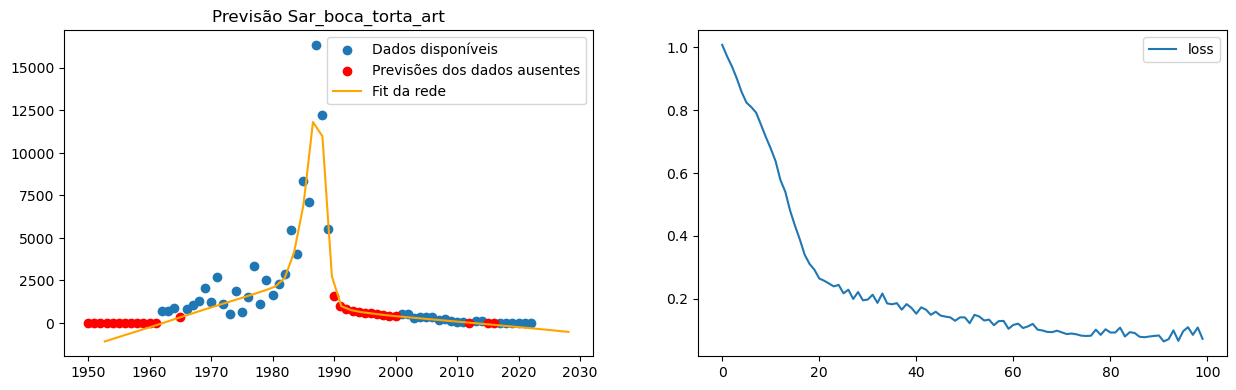

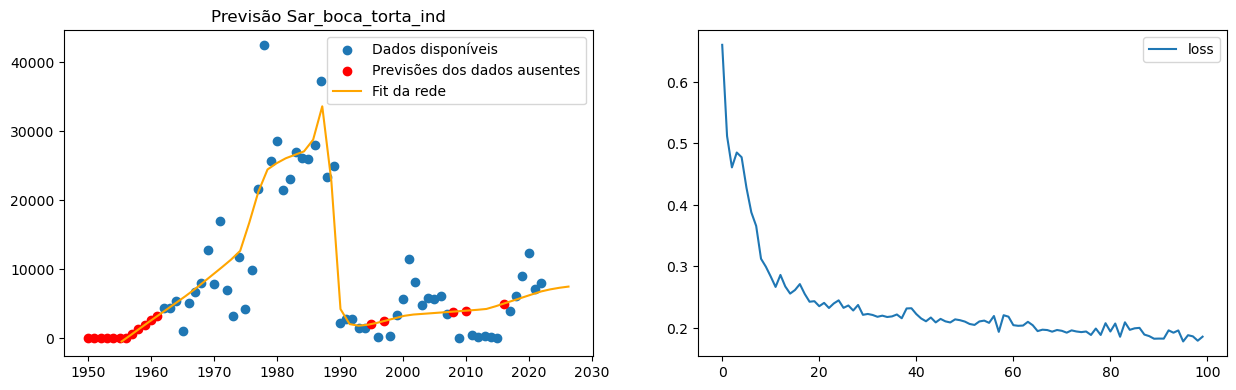

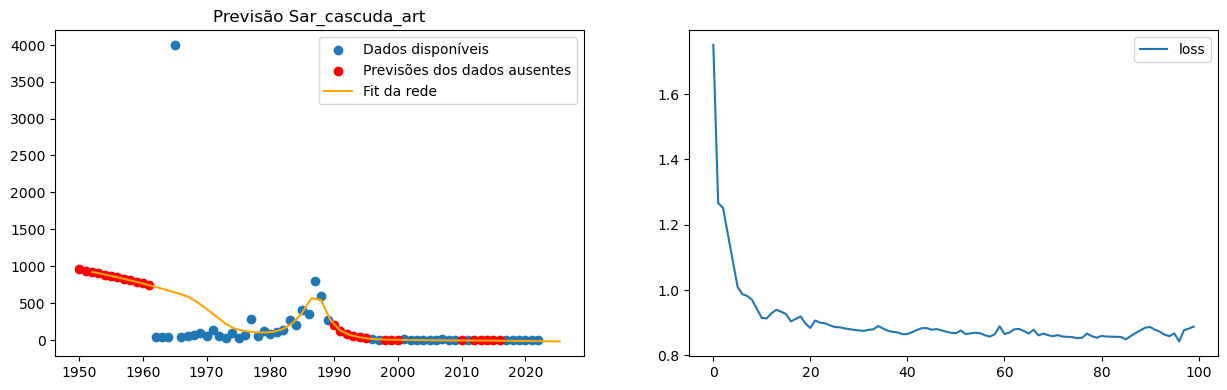

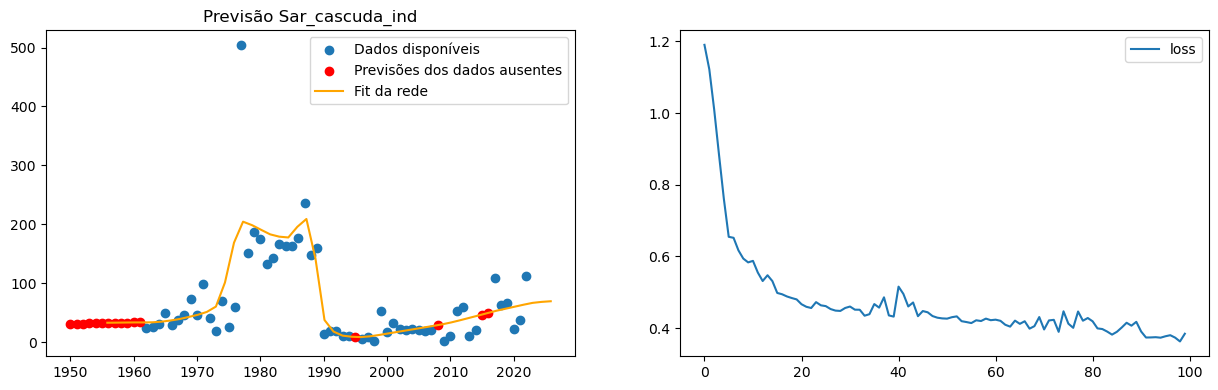

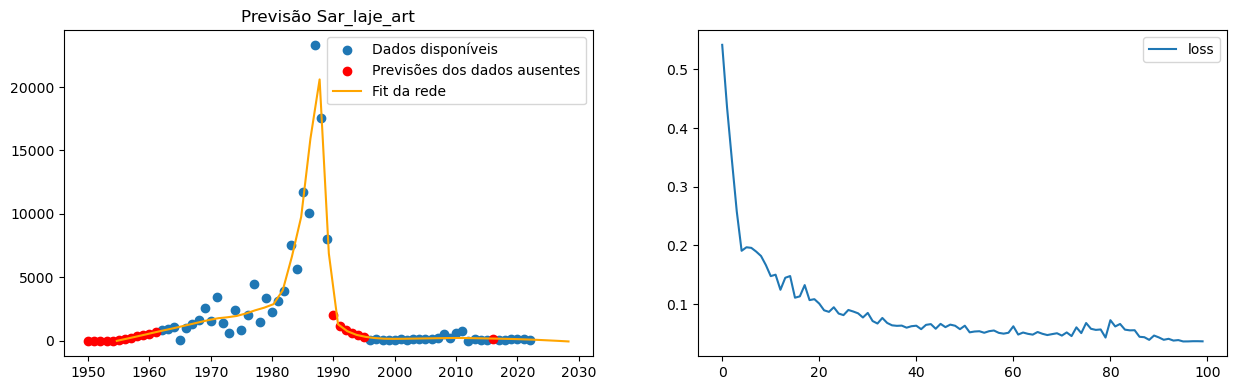

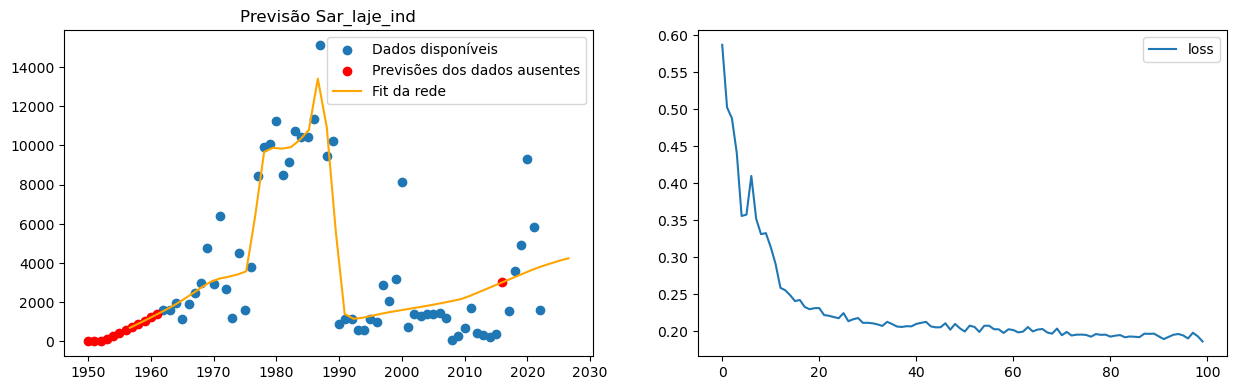

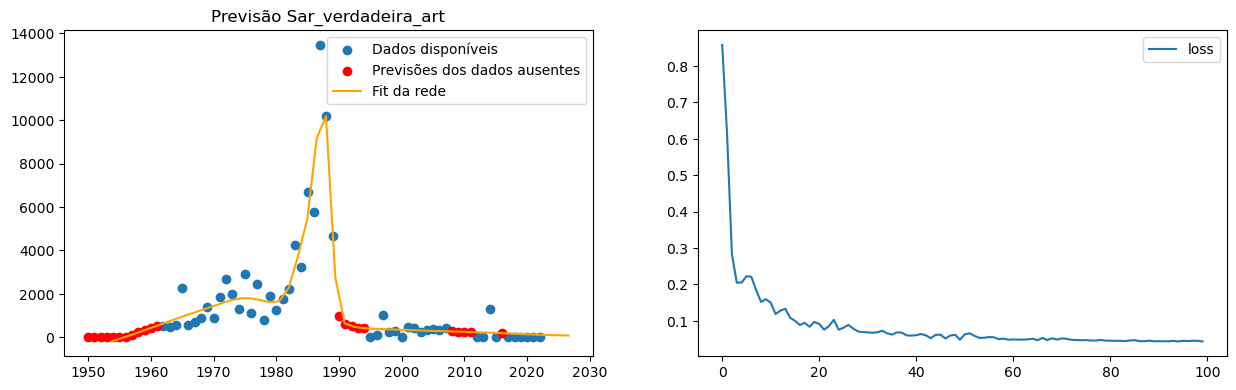

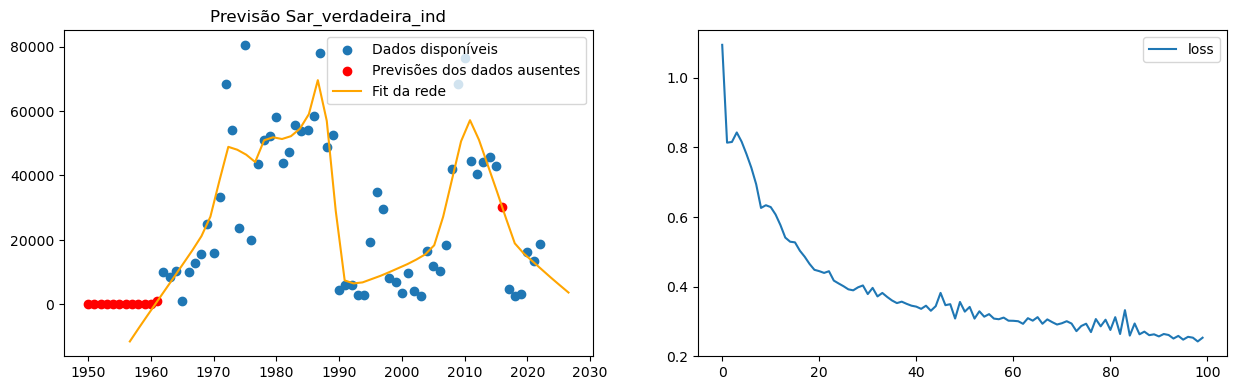

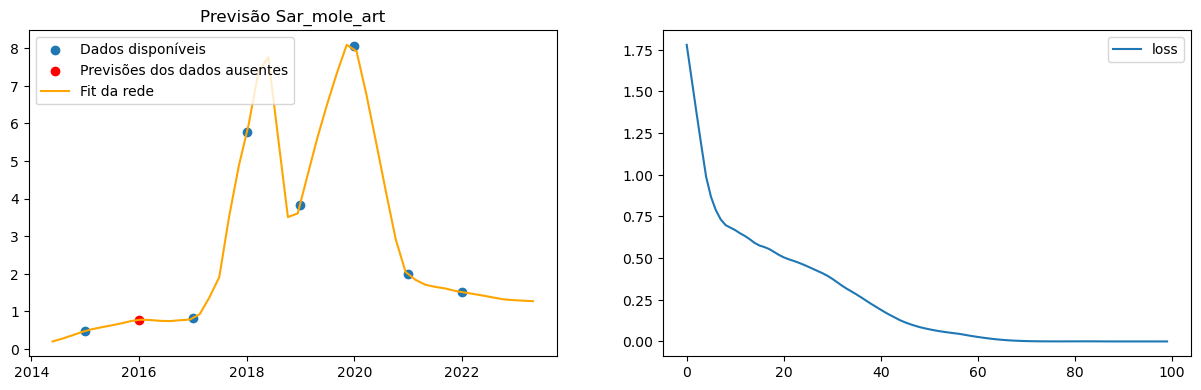

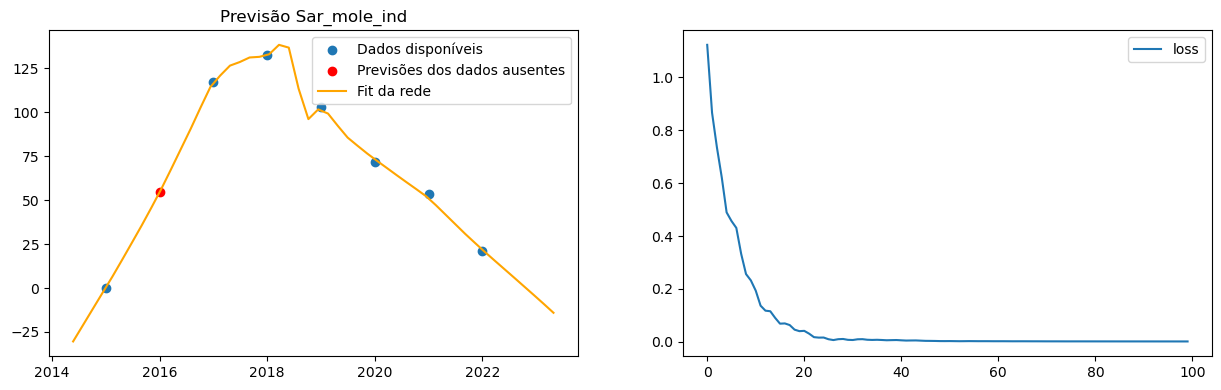

In [19]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_para_prever[k],lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [20]:
#Adicionando aleatoriedade
lista_de_previsoes_rd = copy.deepcopy(lista_de_previsoes)

#Distribuição normal
def normal(x,med,std):
    return (1/(std*np.sqrt(2*np.pi)))*np.exp(-0.5*(((x-med)/std)**2))

#Função para calcular o intervalo de confiança de 90%
def g(k,med,std):
    dx = ((med+k*std)-(med-k*std))/10
    x=[]
    y=[]
    for i in range(11):
        x.append((med-k*std)+i*dx)
        y.append(normal((med-k*std)+i*dx,med,std))
    return integrate.simpson(y,x=x) - 0.90


#Dataframe com os dados reconstruídos
df_prev = df[['Ano',"Sar_boca_torta_art", "Sar_boca_torta_ind", "Sar_cascuda_art", "Sar_cascuda_ind", "Sar_laje_art", "Sar_laje_ind", "Sar_verdadeira_art", "Sar_verdadeira_ind", "Sar_mole_art", "Sar_mole_ind"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_para_prever[k])):
        df_prev.loc[lista_de_anos_para_prever[k][i]-1950,especies[k]] = lista_de_previsoes[k][i,0]

for k in range(len(especies)):
    for i in range(len(lista_de_anos_para_prever[k])):

        #Desvios padrao(5 anos)
        
        #anos_considerados=[]
        valores_considerados=[]
        t=-2
        
        if lista_de_anos_para_prever[k][i]-1950 -2 <0  or pd.isnull(df_prev.loc[lista_de_anos_para_prever[k][i]-1950-2,especies[k]])==True:
            t=-1
        if lista_de_anos_para_prever[k][i]-1950 -1 <0  or pd.isnull(df_prev.loc[lista_de_anos_para_prever[k][i]-1950-1,especies[k]])==True:
            t=0            
        if lista_de_anos_para_prever[k][i]-1950 -2+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_para_prever[k][i]-1950-2+4,especies[k]])==True:
            t=-3
        if lista_de_anos_para_prever[k][i]-1950 -3+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_para_prever[k][i]-1950-3+4,especies[k]])==True:
            t=-4    

        while len(valores_considerados)<5:   
                #anos_considerados.append(lista_de_anos_para_prever[k][i]+t)
                valores_considerados.append(df_prev.loc[lista_de_anos_para_prever[k][i]-1950+t,especies[k]])
                t+=1
        
        #print(lista_de_anos_para_prever[k][i],valores_considerados)
        std = np.std(np.array(valores_considerados))
        med = lista_de_previsoes[k][i,0]
        if std!=0:
          #Raiz da função g(k) pelo método da secante
          raiz = optimize.newton(g,1,args=(med,std))
          
          #Gerando valor aleatorio para a previsão(se houver valores positivos no intervalo)
          prev_min = med - std*raiz
          prev_max = med + std*raiz
          if prev_max>0:
              rd=-1
              #A aleatorização é refeita se o resultado for negativo ou zero
              while rd<=0:
                  rd = np.random.choice(np.linspace(prev_min,prev_max,50))
          else:
              print('A espécie',especies[k],'tem valor(es) negativo(s)')
          lista_de_previsoes_rd[k][i,0]=rd

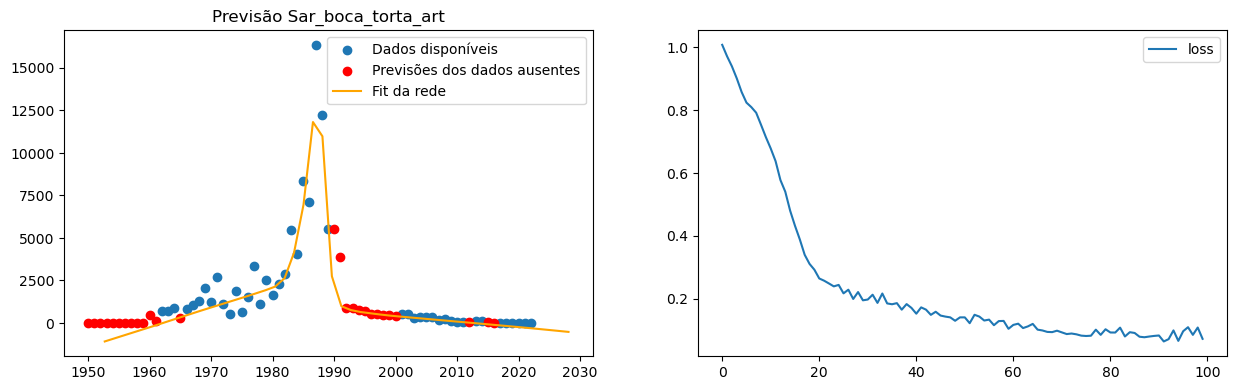

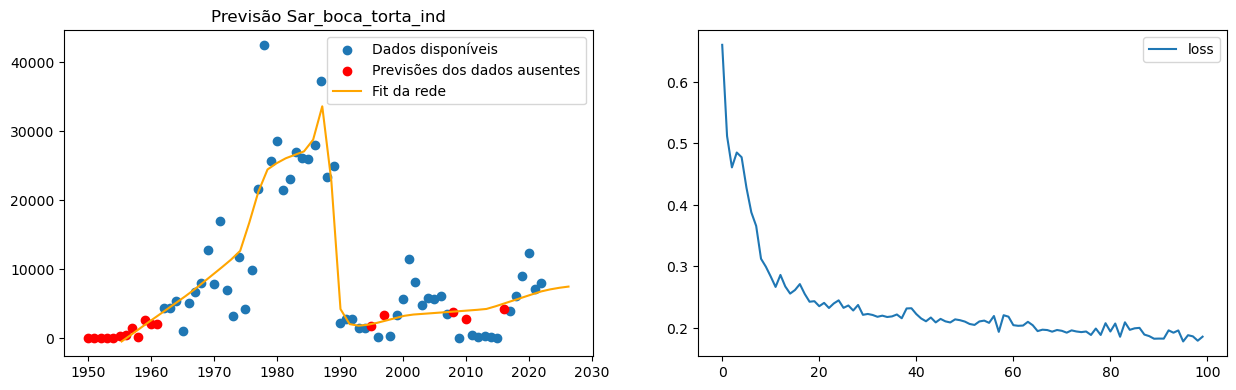

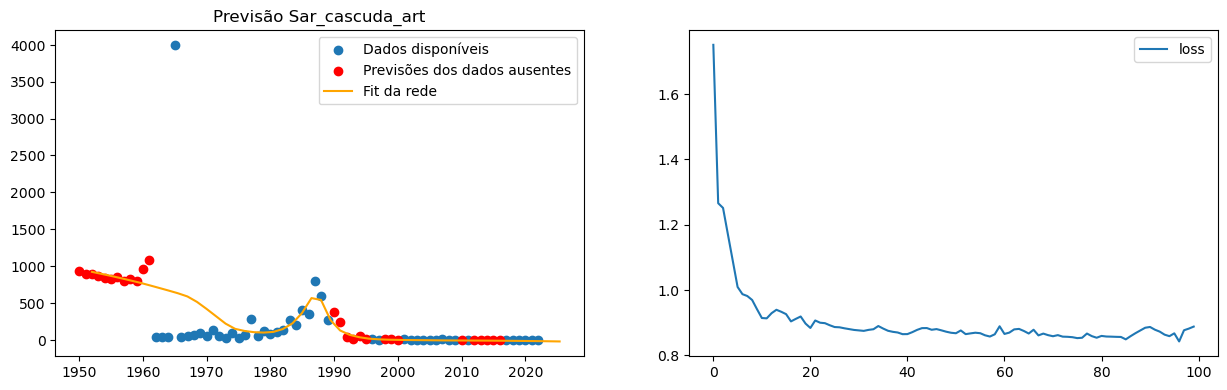

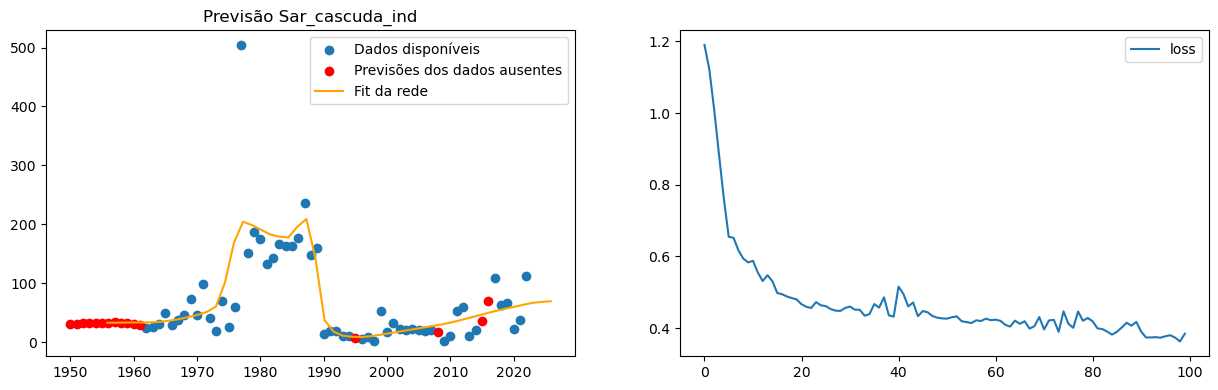

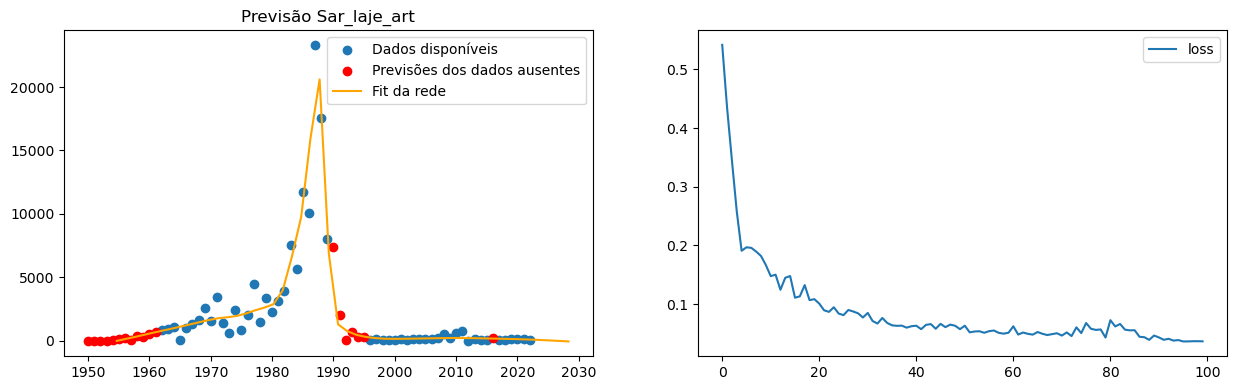

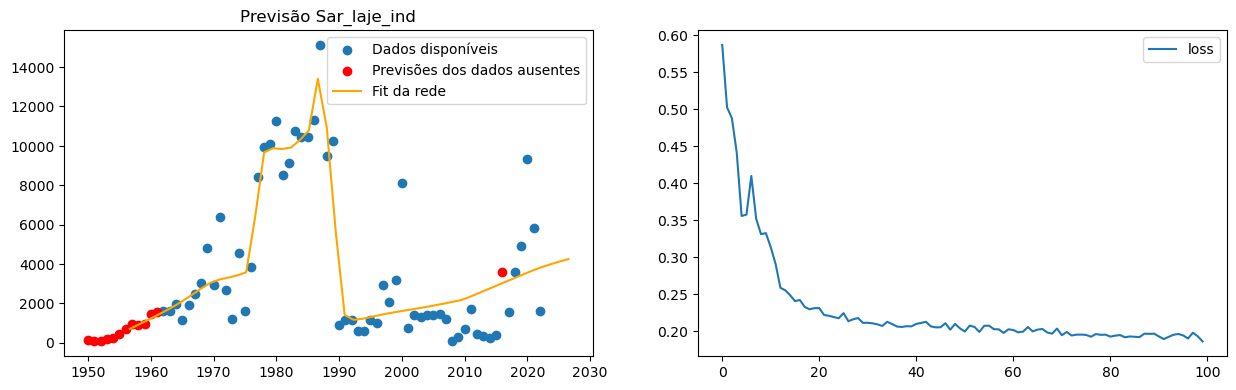

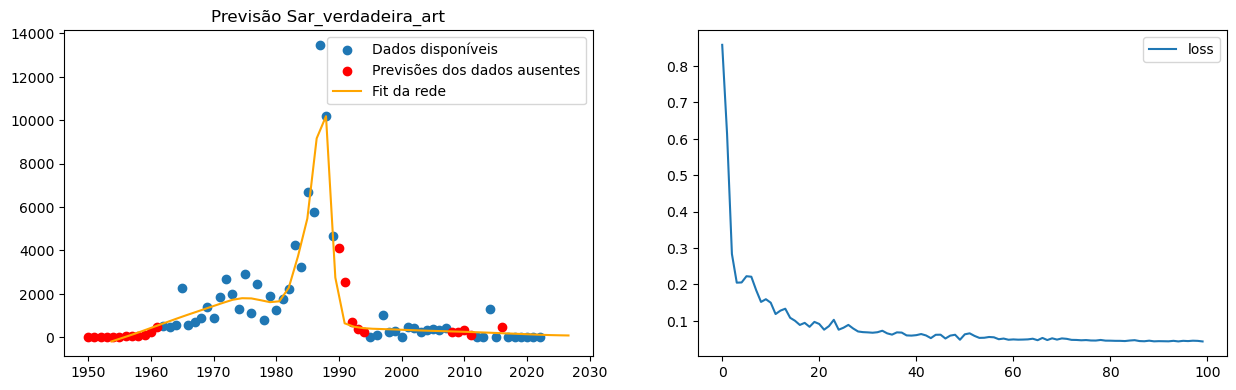

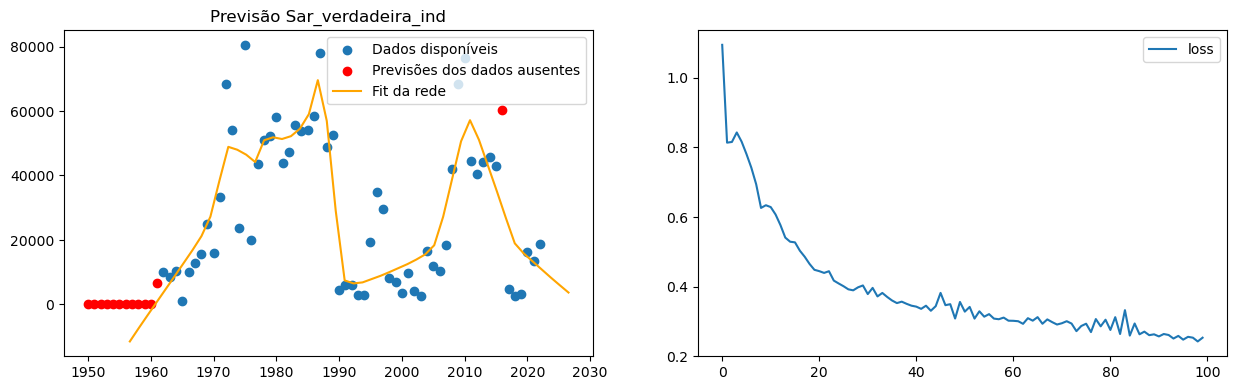

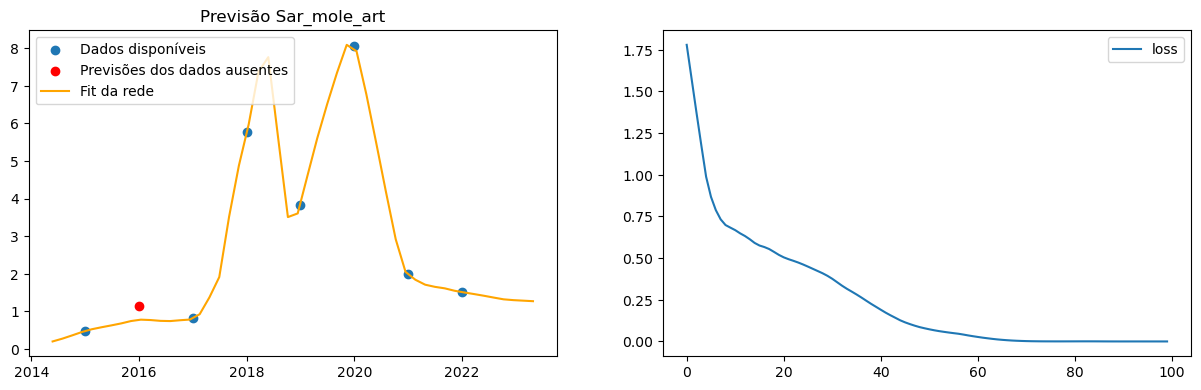

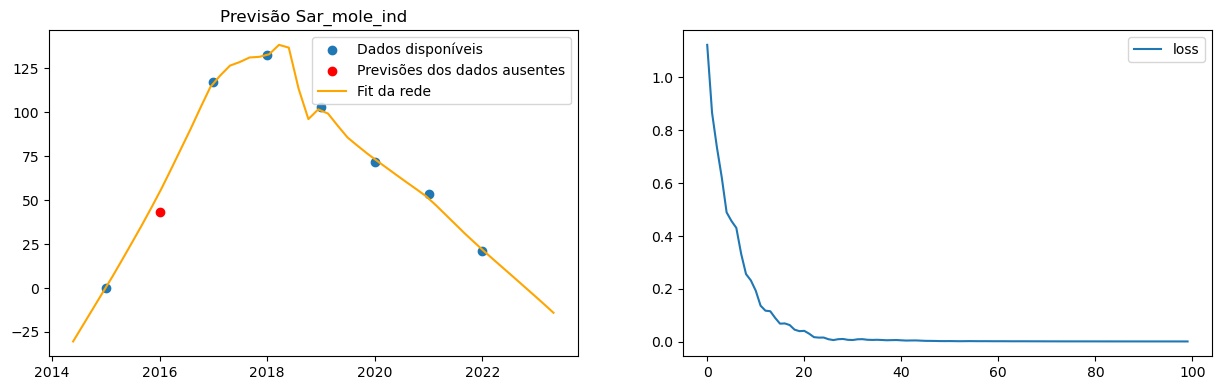

In [21]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_para_prever[k],lista_de_previsoes_rd[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [22]:
#Dicionario dos indices das espécie para prever  (para usar o nome da coluna no openpyxl) 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies)):
    for i in range(len(todas_colunas)):
        if especies[k]==todas_colunas[i]:
            dic_especies[especies[k]]=i+1 #Índices do openpyxl
            break

In [23]:
#ws com os dados preenchidos e coloridos(todos vermelhos)
wb = xl.load_workbook('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/RJ_Reconstrucao_Clupeiformes_2024_08_13.xlsx')
ws = wb.active

for k in range(len(especies)):
    for i in range(len(lista_de_anos_para_prever[k])):
        celula=ws.cell(lista_de_anos_para_prever[k][i]-1950+2 , dic_especies[especies[k]])
        celula.value = lista_de_previsoes_rd[k][i,0]
        celula.font = Font(color='FFFF0000',name='Calibri')


wb.save('Interpolações2.xlsx')


In [24]:
   ###Caso o openpyxl não coloque todos os valores###



df_prev = df[['Ano',"Sar_boca_torta_art", "Sar_boca_torta_ind", "Sar_cascuda_art", "Sar_cascuda_ind", "Sar_laje_art", "Sar_laje_ind", "Sar_verdadeira_art", "Sar_verdadeira_ind", "Sar_mole_art", "Sar_mole_ind"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_para_prever[k])):
        df_prev.loc[lista_de_anos_para_prever[k][i]-1950,especies[k]] = lista_de_previsoes_rd[k][i,0]
df_prev.to_excel('Interpol pandas.xlsx')